# Fusion: poster + text

The poster model in `02_poster_classification.ipynb` scores **0.6175** macro AP. The text model in `01_text_classification.ipynb` scores **0.7268**. Here we check whether combining them beats either one alone.

[LeBaron (Stanford CS230)](http://cs230.stanford.edu/projects_fall_2021/reports/102983714.pdf) fuse four modalities (poster, video, metadata, text) by concatenating output probabilities and training a final fully connected layer on top. We have two modalities, poster and text, and measure three ways of combining them.

| Approach | What the fusion layer sees | Trainable parameters |
|---|---|---|
| Mean fusion | nothing, it is the arithmetic mean of the two probability vectors | 0 |
| Late fusion (paper style) | 13 + 13 output probabilities | 351 |
| Joint fusion | 512-dim CLIP embedding + 384-dim MiniLM embedding, with the last encoder blocks still training | 11.5M |

Both trained variants are fitted on the **train** split and their checkpoint is selected on **val**; test is touched once, at the end.

Short answer: **late fusion wins** (0.7592 macro AP), ahead of mean fusion (0.7479) and of the best single model (0.7268). The joint model reaches 0.7387 with a text branch that is far weaker than TF-IDF, and is the best of the three on the genres the poster carries.

## 1. Setup

Two modalities, two sources of predictions. The poster model saved probabilities for all three splits in `results/poster/predictions_{train,val,test}_clip_vit_b32.csv`. The text pipeline exported `models/text_predictions.npz` (section 11 in `01_text_classification.ipynb`) plus the fitted TF-IDF vectorizer and logistic regression, from which `fusion.data.text_train_scores` recomputes the train probabilities the npz does not carry.

Probability-level fusion therefore runs in seconds on CPU. The joint model is trained separately by `scripts/train_joint_fusion.py`, which reads posters and synopses directly; this notebook only reads its saved metrics.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from fusion.data import load_fusion_inputs
from fusion.metrics import mean_fusion_scores
from helpers import GENRES, PAPER_RESULTS
from poster.metrics import compute_ap_metrics

FUSION = ROOT / "results" / "fusion"
POSTER = ROOT / "results" / "poster"
TEXT_NPZ = ROOT / "models" / "text_predictions.npz"

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## 2. Fusion inputs

All three splits are needed:

- **train (3454 movies):** the fusion head is fitted here
- **val (491 movies):** early stopping and checkpoint selection
- **test (989 movies):** the final score, looked at only at the end

One property of probability-level fusion is worth measuring before using it. Both base models were fitted on train, so their probabilities there are optimistic - the cell below prints how optimistic. The head still learns from them, because train is the split available for learning, and val stays untouched by the fit, so early stopping has a genuinely held-out signal.

In [2]:
data = load_fusion_inputs(
    TEXT_NPZ,
    "logreg",
    POSTER / "predictions_train_clip_vit_b32.csv",
    POSTER / "predictions_val_clip_vit_b32.csv",
    POSTER / "predictions_test_clip_vit_b32.csv",
)

for key in ("poster_train", "text_train", "poster_val", "text_val", "poster_test", "text_test"):
    print(f"{key:13s} {data[key].shape}")

y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

print("\nmacro AP of the base models on the split they were fitted on:")
for name, scores in [("poster", data["poster_train"]), ("text", data["text_train"])]:
    print(f"  {name:7s} {compute_ap_metrics(y_train, scores)['macro_ap']:.4f}")

late = json.loads((FUSION / "test_metrics.json").read_text())
joint = json.loads((ROOT / "results" / "fusion" / "joint" / "metrics.json").read_text())

poster_train  (3454, 13)
text_train    (3454, 13)
poster_val    (491, 13)
text_val      (491, 13)
poster_test   (989, 13)
text_test     (989, 13)

macro AP of the base models on the split they were fitted on:


  poster  0.6687


  text    0.9975


The text model is nearly perfect on its own training data, the poster model is not: the poster head saw each image once, for one epoch, while the logistic regression converged on 50k TF-IDF features. The fusion head has to cope with two differently calibrated inputs, which is one reason to also fuse at feature level (section 3).

A short check that the notebook and `scripts/fuse_predictions.py` are reading the same numbers. If these differ, `movie_id` alignment broke.

In [3]:
check = pd.DataFrame([
    {
        "model": "Poster (CLIP)",
        "notebook": compute_ap_metrics(y_test, data["poster_test"])["macro_ap"],
        "test_metrics.json": late["models"]["poster_only"]["macro_ap"],
    },
    {
        "model": "Text (TF-IDF + LogReg)",
        "notebook": compute_ap_metrics(y_test, data["text_test"])["macro_ap"],
        "test_metrics.json": late["models"]["text_only"]["macro_ap"],
    },
]).set_index("model")
check["abs_diff"] = (check["notebook"] - check["test_metrics.json"]).abs()
display(check.round(6))

,notebook,test_metrics.json,abs_diff
model,,,
Poster (CLIP),0.617520,0.617520,0.0
Text (TF-IDF + LogReg),0.726817,0.726817,0.0


## 3. Three ways to combine

**Mean fusion** is the arithmetic mean of the two probability vectors:

\[ p_{\text{fusion}} = \tfrac{1}{2}\left(p_{\text{poster}} + p_{\text{text}}\right) \]

Zero parameters and no training. It works because the two models fail on different movies: the poster misses `biography`, the text misses `animation`, so the average reduces both errors. Its weakness is that it treats the models as equally good even though text carries more information (0.7268 vs 0.6175), and that it cannot listen to the poster on one genre and ignore it on another.

**Late fusion** is the paper procedure: concatenate the 26 probabilities and map them to 13 outputs with a linear layer, using the same weighted BCE as the base models. 26 x 13 + 13 = **351 parameters**, fitted on the 3454 train movies with mini-batch AdamW, early stopping on val macro AP.

**Joint fusion** (`src/fusion/joint_model.py`) replaces the probabilities with features. CLIP ViT-B/32 produces a 512-dim image embedding, MiniLM a 384-dim sentence embedding, and the head is LayerNorm per modality, `Linear(896, 512)`, ReLU, dropout, `Linear(512, 13)`. The last CLIP block (with `post_layernorm` and `visual_projection`) and the last two MiniLM blocks train together with that head, so the encoders can learn representations that are useful together instead of being two finished opinions. Everything below stays frozen: 11.5M trainable parameters out of 111M.

The text branch has to be MiniLM. TF-IDF + logistic regression is the stronger text model, but it is not a neural encoder and has no last layers to train; MiniLM alone scores 0.5714 macro AP (`01_text_classification.ipynb`, section 12), 0.155 below TF-IDF, because 80% of the synopses are longer than its 256-token window.

In [4]:
comparison = pd.read_csv(FUSION / "comparison_test.csv", index_col=0)
ours = comparison[~comparison.index.str.contains(r"\(rad\)")].copy()

joint_row = pd.DataFrame(
    [[joint["test"]["micro_ap"], joint["test"]["macro_ap"], joint["test"]["sample_ap"]]],
    columns=["AP_micro", "AP_macro", "AP_samples"],
    index=["Joint fusion (CLIP + MiniLM)"],
)
ours = pd.concat([ours, joint_row]).sort_values("AP_macro", ascending=False)

display(ours[["AP_macro", "AP_micro", "AP_samples"]].round(4))

print("mean fusion check:",
      round(compute_ap_metrics(y_test, mean_fusion_scores(data["poster_test"], data["text_test"]))["macro_ap"], 4))

,AP_macro,AP_micro,AP_samples
Late fusion (clip_vit_b32 + logreg),0.7592,0.8122,0.8752
Mean fusion (poster + text),0.7479,0.7915,0.8618
Joint fusion (CLIP + MiniLM),0.7387,0.7630,0.8252
Text (TF-IDF + LogReg),0.7268,0.7733,0.8430
Poster (clip_vit_b32),0.6175,0.6219,0.7416


mean fusion check: 0.7479


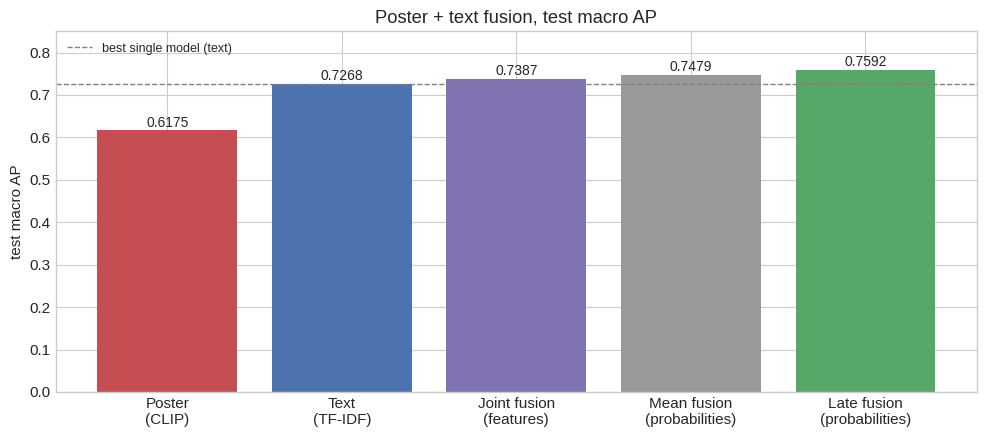

In [5]:
order = ["Poster (clip_vit_b32)", "Text (TF-IDF + LogReg)", "Joint fusion (CLIP + MiniLM)",
         "Mean fusion (poster + text)", "Late fusion (clip_vit_b32 + logreg)"]
labels = ["Poster\n(CLIP)", "Text\n(TF-IDF)", "Joint fusion\n(features)",
          "Mean fusion\n(probabilities)", "Late fusion\n(probabilities)"]
values = [ours.loc[m, "AP_macro"] for m in order]
colors = ["#C44E52", "#4C72B0", "#8172B2", "#999999", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(ours.loc["Text (TF-IDF + LogReg)", "AP_macro"], color="gray",
           linestyle="--", linewidth=1, label="best single model (text)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f"{v:.4f}", ha="center", fontsize=10)
ax.set_ylabel("test macro AP")
ax.set_ylim(0, 0.85)
ax.set_title("Poster + text fusion, test macro AP")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Result

| Model | macro AP | vs text |
|---|---|---|
| Late fusion (paper style) | **0.7592** | **+0.032** |
| Mean fusion (poster + text) | 0.7479 | +0.021 |
| Joint fusion (CLIP + MiniLM) | 0.7387 | +0.012 |
| Text (TF-IDF + LogReg) | 0.7268 | 0 |
| Poster (CLIP) | 0.6175 | -0.109 |

Three findings:

1. **The poster carries information that is not in the plot.** Every fusion beats text alone, and plain averaging already gains +0.021 even though the poster model is much weaker. If the poster were noise, averaging would hurt.
2. **A trained layer beats the average**, +0.011, because it can weight the two modalities per genre instead of at 50/50 - the per-genre view in section 6 shows where that matters.
3. **Feature-level fusion is competitive with a much weaker text branch.** The joint model is +0.012 over TF-IDF while reading synopses through MiniLM, which alone is 0.155 below TF-IDF. Section 6 shows it converts that into the best result of all three on the visual genres.

## 5. What the trained variants do on held-out data

Both trained variants fit on train and select on val, so their val score is a score on data no gradient step used. The table compares val against test, and the curves show how each one converged.

In [6]:
held_out = pd.DataFrame([
    {
        "model": "Late fusion (probabilities)",
        "fitted on": f"train ({len(y_train)})",
        "val macro AP": late["fusion_training"]["best_val_macro_ap"],
        "test macro AP": late["models"]["late_fusion"]["macro_ap"],
    },
    {
        "model": "Joint fusion (features)",
        "fitted on": f"train ({joint['config']['train_size']})",
        "val macro AP": joint["training"]["best_val_macro_ap"],
        "test macro AP": joint["test"]["macro_ap"],
    },
]).set_index("model")
display(held_out.round(4))

print(f"late fusion:  best epoch {late['fusion_training']['best_epoch']} "
      f"of {len(late['fusion_training']['history'])} run, "
      f"macro AP on the fitted rows {late['fusion_training']['train_macro_ap_at_best']:.4f}")
print(f"joint fusion: best epoch {joint['training']['best_epoch']} "
      f"of {len(joint['training']['history'])} run, "
      f"{joint['parameters']['trainable']:,} trainable parameters, "
      f"{joint['elapsed_seconds'] / 60:.0f} min on {joint['config']['device']}")

,fitted on,val macro AP,test macro AP
model,,,
Late fusion (probabilities),train (3454),0.7497,0.7592
Joint fusion (features),train (3454),0.7245,0.7387


late fusion:  best epoch 192 of 222 run, macro AP on the fitted rows 0.9946
joint fusion: best epoch 3 of 6 run, 11,499,277 trainable parameters, 79 min on cpu


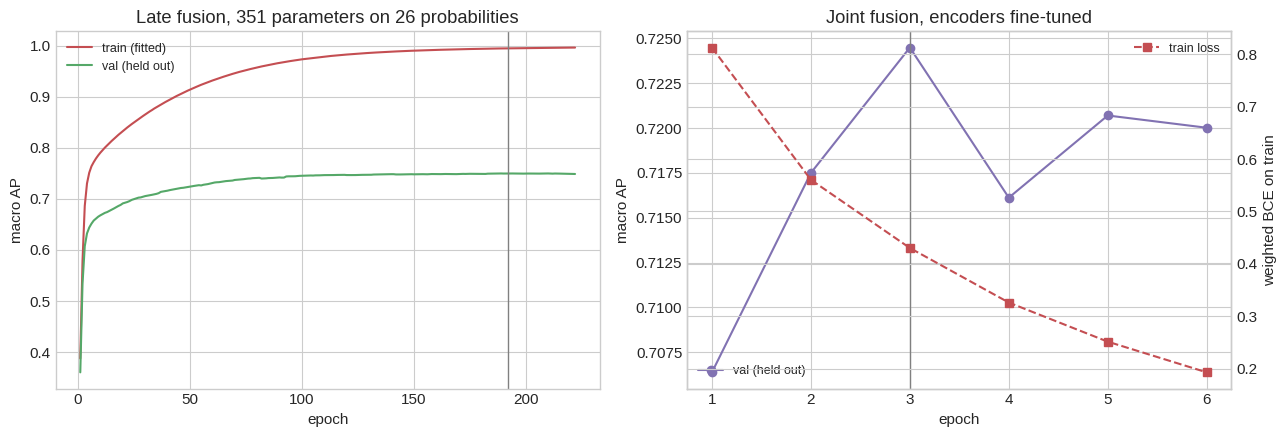

,train_loss,val_macro_ap,val_micro_ap,seconds
epoch,,,,
1,0.8131,0.7064,0.6834,771.3
2,0.5605,0.7175,0.7421,766.3
3,0.4302,0.7245,0.7569,763.0
4,0.3260,0.7161,0.7614,767.7
5,0.2513,0.7207,0.7570,762.7
6,0.1927,0.7200,0.7755,766.3


In [7]:
late_hist = pd.DataFrame(late["fusion_training"]["history"]).set_index("epoch")
joint_hist = pd.DataFrame(joint["training"]["history"]).set_index("epoch")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(late_hist.index, late_hist["train_macro_ap"], color="#C44E52", label="train (fitted)")
axes[0].plot(late_hist.index, late_hist["val_macro_ap"], color="#55A868", label="val (held out)")
axes[0].axvline(late["fusion_training"]["best_epoch"], color="gray", linewidth=1)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("macro AP")
axes[0].set_title("Late fusion, 351 parameters on 26 probabilities")
axes[0].legend(fontsize=9)

axes[1].plot(joint_hist.index, joint_hist["val_macro_ap"], "o-", color="#8172B2", label="val (held out)")
axes[1].axvline(joint["training"]["best_epoch"], color="gray", linewidth=1)
ax_loss = axes[1].twinx()
ax_loss.plot(joint_hist.index, joint_hist["train_loss"], "s--", color="#C44E52", label="train loss")
ax_loss.set_ylabel("weighted BCE on train")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro AP")
axes[1].set_title("Joint fusion, encoders fine-tuned")
axes[1].legend(fontsize=9, loc="lower left")
ax_loss.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

display(joint_hist.round(4))

Two different shapes of the same behaviour.

**Late fusion** reaches 0.9946 macro AP on the rows it fits and 0.7497 on val. That gap is not overfitting of the layer - 351 parameters cannot memorise 3454 movies - it is the base models being nearly perfect in-sample, so the head sees inputs that look better than they are on unseen data. AP depends only on ranking, and the ranking learned there still transfers: val 0.7497, test 0.7592.

**Joint fusion** peaks on val at epoch 3 while the training loss keeps falling, the ordinary picture of a fine-tuned transformer on 3454 examples. Early stopping keeps the epoch-3 checkpoint; the epochs after it fit the train split only. Each epoch is 216 steps of batch 16 and takes about 12.5 minutes on CPU, which is what bounds the search to 8 epochs and three unfrozen blocks.

## 6. By genre: where the poster actually helps

0.7592 against 0.7268 macro AP sounds small. The per-genre breakdown shows it is not small, it is concentrated.

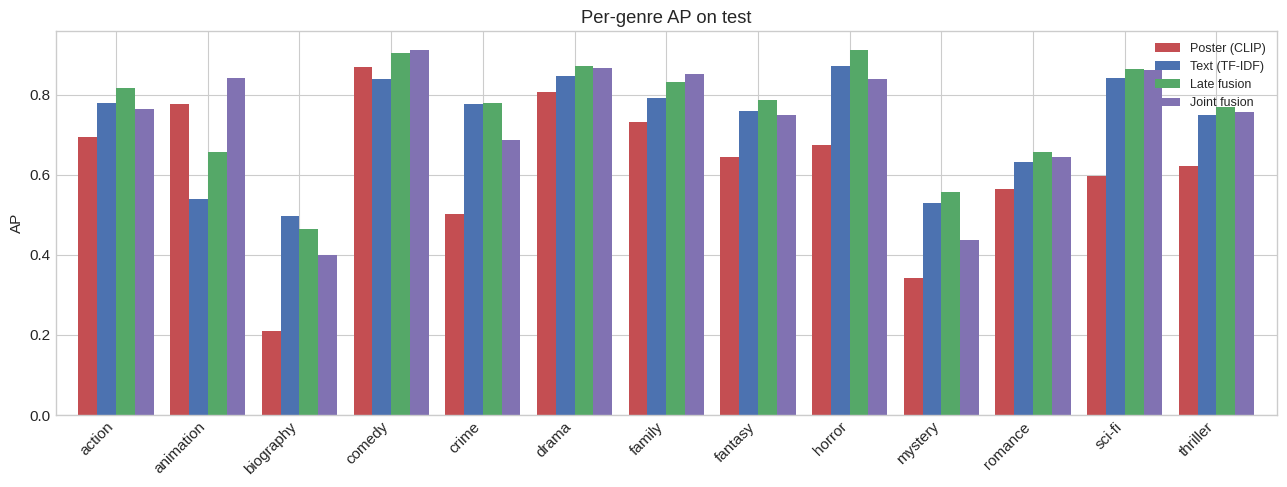

,Poster (CLIP),Text (TF-IDF),Mean fusion,Late fusion,Joint fusion
action,0.694,0.779,0.807,0.817,0.763
animation,0.777,0.539,0.691,0.657,0.841
biography,0.209,0.498,0.410,0.465,0.400
comedy,0.870,0.839,0.912,0.903,0.910
crime,0.501,0.776,0.752,0.779,0.687
drama,0.805,0.845,0.868,0.872,0.867
family,0.732,0.792,0.833,0.830,0.850
fantasy,0.644,0.759,0.766,0.787,0.749
horror,0.674,0.871,0.895,0.912,0.838
mystery,0.341,0.530,0.529,0.556,0.437


In [8]:
per_genre = pd.DataFrame({
    "Poster (CLIP)": late["models"]["poster_only"]["per_genre_ap"],
    "Text (TF-IDF)": late["models"]["text_only"]["per_genre_ap"],
    "Mean fusion": late["models"]["mean_fusion"]["per_genre_ap"],
    "Late fusion": late["models"]["late_fusion"]["per_genre_ap"],
    "Joint fusion": joint["test"]["per_genre_ap"],
}).loc[GENRES]

fig, ax = plt.subplots(figsize=(13, 5))
per_genre[["Poster (CLIP)", "Text (TF-IDF)", "Late fusion", "Joint fusion"]].plot(
    kind="bar", ax=ax, width=0.82, color=["#C44E52", "#4C72B0", "#55A868", "#8172B2"]
)
ax.set_ylabel("AP")
ax.set_title("Per-genre AP on test")
plt.xticks(rotation=45, ha="right")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

display(per_genre.round(3))

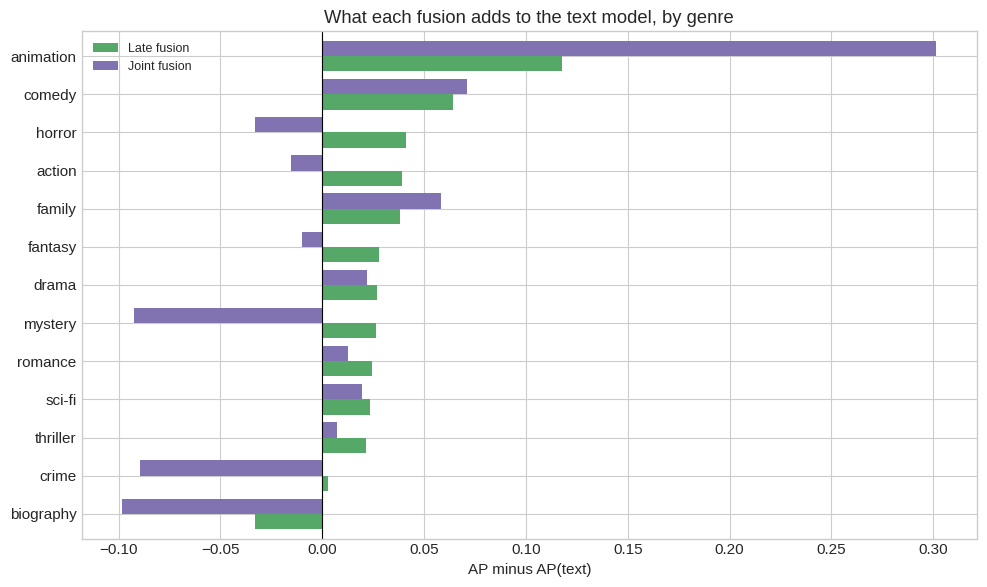

In [9]:
delta = pd.DataFrame({
    "Late fusion": per_genre["Late fusion"] - per_genre["Text (TF-IDF)"],
    "Joint fusion": per_genre["Joint fusion"] - per_genre["Text (TF-IDF)"],
}).sort_values("Late fusion")

fig, ax = plt.subplots(figsize=(10, 6))
delta.plot(kind="barh", ax=ax, color=["#55A868", "#8172B2"], width=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AP minus AP(text)")
ax.set_title("What each fusion adds to the text model, by genre")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The effect is very uneven, and the two fusions are strong in different places.

- **`animation`** is the cleanest complementary signal in the project. The poster (0.777) is far better than text (0.539), because drawing style is obvious at a glance while an animated synopsis does not read differently from a live-action one. Joint fusion reaches **0.841** here, above every other model, including the poster model that carries the signal: fusing at feature level lets one decision use both inputs, instead of averaging two finished opinions. Late fusion gets 0.657.
- **`family` 0.850** is the same story, again the best of the five. **`comedy`** is a draw: 0.910 for joint fusion, 0.912 for the plain average, 0.903 for late fusion. Comedy posters have a recognisable language - close-up faces, bright palette, large title - and every model that sees the poster picks it up.
- **`biography` -0.033 for late fusion** and -0.098 for joint fusion. The poster (0.209) is close to useless there - a biography poster looks like a drama poster - so any weight given to it costs.
- **On the genres the synopsis gives away, late fusion wins:** `horror` 0.912 against 0.838, `crime` 0.779 against 0.687, `mystery` 0.556 against 0.437. These are exactly the genres where the full document matters, and this is the 256-token window of MiniLM showing up: the joint model reads at most the first quarter of a typical synopsis, TF-IDF reads all of it.

That last point is the whole 0.02 difference between the two trained fusions. It is a property of the text encoder, not of the fusion method: the branch the joint model is allowed to fine-tune starts 0.155 macro AP behind the one late fusion consumes.

## 7. Comparison with the paper

The paper reports macro AP per modality and for the four-way combination. Our results and their numbers, same dataset, same metric:

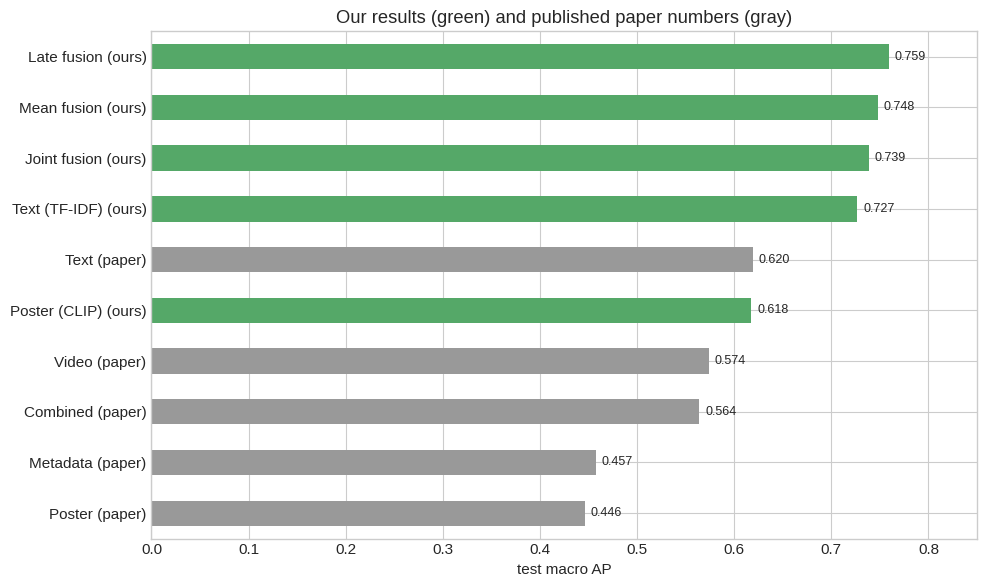

,AP_micro,AP_macro,AP_samples
Poster (paper),0.5201,0.4463,0.6572
Metadata (paper),0.4944,0.4574,0.6284
Combined (paper),0.6270,0.5641,0.7358
Video (paper),0.5899,0.5739,0.6964
Poster (CLIP) (ours),0.6219,0.6175,0.7416
Text (paper),0.6317,0.6195,0.7497
Text (TF-IDF) (ours),0.7733,0.7268,0.8430
Joint fusion (ours),0.7630,0.7387,0.8252
Mean fusion (ours),0.7915,0.7479,0.8618
Late fusion (ours),0.8122,0.7592,0.8752


In [10]:
context = PAPER_RESULTS.copy()
context.index = [f"{i.replace(' (rad)', '')} (paper)" for i in context.index]

for label, block in [
    ("Poster (CLIP) (ours)", late["models"]["poster_only"]),
    ("Text (TF-IDF) (ours)", late["models"]["text_only"]),
    ("Mean fusion (ours)", late["models"]["mean_fusion"]),
    ("Late fusion (ours)", late["models"]["late_fusion"]),
    ("Joint fusion (ours)", joint["test"]),
]:
    context.loc[label] = [block["micro_ap"], block["macro_ap"], block["sample_ap"]]

context = context.sort_values("AP_macro")
colors = ["#999999" if "(paper)" in i else "#55A868" for i in context.index]

fig, ax = plt.subplots(figsize=(10, 6))
context["AP_macro"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("test macro AP")
ax.set_title("Our results (green) and published paper numbers (gray)")
for i, v in enumerate(context["AP_macro"]):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 0.85)
plt.tight_layout()
plt.show()

display(context.round(4))

Read the comparison with one limitation: **their combination uses four modalities, ours uses two.** We did not train video or metadata models (trailers are not available as training files; metadata is tabular IMDb fields and was the weakest modality in the paper), so "Combined (paper)" and our fusions are not the same thing. With that said:

- Our late fusion is **0.7592** against their **0.5641** combined, +0.195 macro AP with two modalities instead of four. Most of that comes from the base models: CLIP instead of ImageNet VGG (+0.17 on poster alone) and TF-IDF + logistic regression instead of GloVe + MLP (+0.11 on text alone).
- **Their combination was worse than their best single modality** (0.5641 against 0.6195 for text). Ours is not: both trained fusions are above TF-IDF. The difference is the amount of data the fusion layer is fitted on and, for the joint model, that it fuses representations rather than finished predictions.

## 8. Conclusions

1. **Fusion is worth it:** 0.7592 macro AP against 0.7268 for the best single model. The poster carries information that is not in the plot.
2. **The trained layer beats the average** (0.7592 against 0.7479) because the modalities deserve different weights per genre, and 3454 training movies are enough to estimate 351 parameters.
3. **Feature-level fusion with fine-tuned encoders wins the visual genres:** `animation` 0.841 and `family` 0.850 are the best in the project and `comedy` 0.910 is level with the best, at 0.7387 overall despite a text branch 0.155 macro AP behind TF-IDF. The obvious next step is a text encoder that reads the whole synopsis rather than its first 256 tokens.
4. **Poster gain is concentrated:** `animation` +0.118, `comedy` +0.064 and `family` +0.038 over text for late fusion, while `biography` loses 0.033 because that genre has no visual signature.
5. **Same-modality, we are above the paper** (CLIP poster against their poster, TF-IDF against their GloVe MLP). Combination against combination is not the same comparison: they fuse four modalities, we fuse two.

### Reproduction

```bash
# 1. text predictions: notebooks/01_text_classification.ipynb, section 11
#    -> models/text_predictions.npz
# 2. poster probabilities for all three splits
python scripts/predict.py --backbone clip_vit_b32 --split-dir train_data --device mps --batch-size 16
python scripts/predict.py --backbone clip_vit_b32 --split-dir val_data --device mps --batch-size 16
python scripts/predict.py --backbone clip_vit_b32 --split-dir test_data --device mps --batch-size 16
# 3. mean fusion and late fusion
python scripts/fuse_predictions.py --device cpu
# 4. joint fusion
python scripts/train_joint_fusion.py --device mps
```